<a href="https://colab.research.google.com/github/triksoft/Machine_Learning/blob/main/ML_Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mne scipy scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 56.1 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
# ============================================================
# LAB 05 - A1, A2, A7
# Custom kNN + Weighted kNN for EEG Schizophrenia Dataset
# ============================================================

import os
import zipfile
import numpy as np
import pandas as pd
import mne

from collections import Counter, defaultdict
from scipy.signal import welch

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# ============================================================
# 1. EXTRACT DATASET
# ============================================================

def extract_dataset(zip_path, extract_path):
    """
    Extract the uploaded dataverse_files.zip file.
    """
    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    return extract_path


# ============================================================
# 2. FIND EDF FILES
# ============================================================

def find_edf_files(folder):
    """
    Find all EDF files recursively.
    """
    edf_files = []

    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(".edf"):
                edf_files.append(os.path.join(root, file))

    edf_files.sort()

    return edf_files


# ============================================================
# 3. CREATE LABEL FROM FILE NAME
# ============================================================

def get_label(file_path):
    """
    h01-h14 -> Healthy
    s01-s14 -> Schizophrenia
    """

    filename = os.path.basename(file_path).lower()

    if filename.startswith("h"):
        return "Healthy"

    elif filename.startswith("s"):
        return "Schizophrenia"

    else:
        return None


# ============================================================
# 4. EEG FEATURE EXTRACTION
# ============================================================

def extract_eeg_features(file_path):
    """
    Convert an EDF EEG recording into one numerical
    feature vector.

    Features:
        Delta power
        Theta power
        Alpha power
        Beta power
        Gamma power

    for every EEG channel.
    """

    raw = mne.io.read_raw_edf(
        file_path,
        preload=True,
        verbose=False
    )

    # Keep EEG channels only
    raw.pick("eeg")

    # Remove DC offset
    raw.apply_function(
        lambda x: x - np.mean(x),
        channel_wise=True
    )

    data = raw.get_data()

    sfreq = raw.info["sfreq"]

    # Frequency bands
    bands = {
        "delta": (0.5, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta": (13, 30),
        "gamma": (30, 45)
    }

    features = []

    # Calculate PSD for each channel
    for channel in data:

        frequencies, psd = welch(
            channel,
            fs=sfreq,
            nperseg=min(1024, len(channel))
        )

        for band_name, (low, high) in bands.items():

            band_mask = (
                (frequencies >= low) &
                (frequencies <= high)
            )

            band_power = np.trapezoid(
                psd[band_mask],
                frequencies[band_mask]
            )

            features.append(band_power)

    return np.array(features)


# ============================================================
# 5. LOAD COMPLETE EEG DATASET
# ============================================================

def load_dataset(edf_files):
    """
    Load all EDF files and create X and y.
    """

    X = []
    y = []
    filenames = []

    for file_path in edf_files:

        label = get_label(file_path)

        if label is None:
            continue

        try:

            features = extract_eeg_features(file_path)

            X.append(features)
            y.append(label)
            filenames.append(os.path.basename(file_path))

            print(
                "Loaded:",
                os.path.basename(file_path),
                "->",
                label
            )

        except Exception as e:

            print(
                "Error loading",
                file_path,
                ":",
                e
            )

    return np.array(X), np.array(y), filenames


# ============================================================
# 6. DATA IMPUTATION
# ============================================================

def impute_data(X, strategy="median"):
    """
    Fill missing values.

    strategy:
        mean
        median
        most_frequent
    """

    imputer = SimpleImputer(strategy=strategy)

    X_imputed = imputer.fit_transform(X)

    return X_imputed, imputer


# ============================================================
# 7. FEATURE STANDARDIZATION
# ============================================================

def standardize_data(X):
    """
    Standardize features so that distance calculations
    are not dominated by large-valued features.
    """

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    return X_scaled, scaler


# ============================================================
# 8. DISTANCE CALCULATION
# ============================================================

def calculate_distance(a, b, metric="euclidean"):
    """
    Calculate distance between two feature vectors.
    """

    if metric == "euclidean":

        return np.sqrt(np.sum((a - b) ** 2))

    elif metric == "manhattan":

        return np.sum(np.abs(a - b))

    elif metric == "chebyshev":

        return np.max(np.abs(a - b))

    else:

        raise ValueError(
            "Unknown distance metric"
        )


# ============================================================
# 9. SORTING ALGORITHM 1 - BUBBLE SORT
# ============================================================

def bubble_sort(distances):

    arr = distances.copy()

    n = len(arr)

    for i in range(n):

        for j in range(0, n - i - 1):

            if arr[j][0] > arr[j + 1][0]:

                arr[j], arr[j + 1] = (
                    arr[j + 1],
                    arr[j]
                )

    return arr


# ============================================================
# 10. SORTING ALGORITHM 2 - INSERTION SORT
# ============================================================

def insertion_sort(distances):

    arr = distances.copy()

    for i in range(1, len(arr)):

        key = arr[i]

        j = i - 1

        while (
            j >= 0
            and arr[j][0] > key[0]
        ):

            arr[j + 1] = arr[j]

            j -= 1

        arr[j + 1] = key

    return arr


# ============================================================
# 11. SORTING ALGORITHM 3 - SELECTION SORT
# ============================================================

def selection_sort(distances):

    arr = distances.copy()

    n = len(arr)

    for i in range(n):

        min_index = i

        for j in range(i + 1, n):

            if arr[j][0] < arr[min_index][0]:

                min_index = j

        arr[i], arr[min_index] = (
            arr[min_index],
            arr[i]
        )

    return arr


# ============================================================
# 12. SELECT SORTING ALGORITHM
# ============================================================

def sort_distances(distances, algorithm="insertion"):

    if algorithm == "bubble":

        return bubble_sort(distances)

    elif algorithm == "insertion":

        return insertion_sort(distances)

    elif algorithm == "selection":

        return selection_sort(distances)

    else:

        raise ValueError(
            "Choose bubble, insertion or selection"
        )


# ============================================================
# 13. TIE BREAKING
# ============================================================

def majority_vote(neighbors):

    class_counts = Counter()

    class_distances = defaultdict(float)

    for distance, label in neighbors:

        class_counts[label] += 1
        class_distances[label] += distance

    max_votes = max(class_counts.values())

    candidates = [
        label
        for label, count in class_counts.items()
        if count == max_votes
    ]

    # Tie-breaking:
    # choose the class whose neighbors have
    # smaller total distance.

    if len(candidates) > 1:

        candidates.sort(
            key=lambda label: (
                class_distances[label],
                str(label)
            )
        )

    return candidates[0]


# ============================================================
# 14. WEIGHTED VOTING
# ============================================================

def weighted_vote(neighbors):

    class_weights = defaultdict(float)

    class_distances = defaultdict(float)

    for distance, label in neighbors:

        # Avoid division by zero
        weight = 1 / (distance + 1e-10)

        class_weights[label] += weight

        class_distances[label] += distance

    max_weight = max(class_weights.values())

    candidates = [
        label
        for label, weight in class_weights.items()
        if np.isclose(weight, max_weight)
    ]

    # Tie breaking
    if len(candidates) > 1:

        candidates.sort(
            key=lambda label: (
                class_distances[label],
                str(label)
            )
        )

    return candidates[0]


# ============================================================
# 15. CUSTOM KNN CLASSIFIER
# ============================================================

class CustomKNN:

    def __init__(
        self,
        k=3,
        metric="euclidean",
        sorting_algorithm="insertion",
        weighted=False
    ):

        self.k = k

        self.metric = metric

        self.sorting_algorithm = sorting_algorithm

        self.weighted = weighted

        self.X_train = None

        self.y_train = None


    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    def fit(self, X, y):

        self.X_train = np.array(X)

        self.y_train = np.array(y)

        return self


    # --------------------------------------------------------
    # PREDICT ONE SAMPLE
    # --------------------------------------------------------

    def predict_one(self, x):

        distances = []

        for i in range(len(self.X_train)):

            distance = calculate_distance(
                x,
                self.X_train[i],
                self.metric
            )

            distances.append(
                (distance, self.y_train[i])
            )

        # Sort distances
        sorted_distances = sort_distances(
            distances,
            self.sorting_algorithm
        )

        # Select k nearest neighbors
        neighbors = sorted_distances[:self.k]

        # Weighted or normal voting
        if self.weighted:

            return weighted_vote(neighbors)

        else:

            return majority_vote(neighbors)


    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    def predict(self, X):

        predictions = []

        for x in X:

            predictions.append(
                self.predict_one(x)
            )

        return np.array(predictions)


    # --------------------------------------------------------
    # SCORE
    # --------------------------------------------------------

    def score(self, X, y):

        predictions = self.predict(X)

        return np.mean(predictions == y)


# ============================================================
# END OF MODULAR FUNCTIONS
# ============================================================

In [ ]:
# ============================================================
# LOAD EEG DATA
# ============================================================

# Define paths
zip_path = "/content/dataverse_files.zip"
extract_path = "/content/eeg_dataset"

# 1. Extract the dataset
extract_dataset(zip_path, extract_path)

# 2. Find all EDF files
edf_files = find_edf_files(extract_path)

X, y, filenames = load_dataset(edf_files)

print("\n========================================")
print("DATASET INFORMATION")
print("========================================")

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nFeature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

print("\nClass distribution:")
print(pd.Series(y).value_counts())

print("\nFirst 5 files:")
for i in range(min(5, len(filenames))):
    print(filenames[i], "->", y[i])

Loaded: h01.edf -> Healthy
Loaded: h02.edf -> Healthy
Loaded: h03.edf -> Healthy
Loaded: h04.edf -> Healthy
Loaded: h05.edf -> Healthy
Loaded: h06.edf -> Healthy
Loaded: h07.edf -> Healthy
Loaded: h08.edf -> Healthy
Loaded: h09.edf -> Healthy
Loaded: h10.edf -> Healthy
Loaded: h11.edf -> Healthy
Loaded: h12.edf -> Healthy
Loaded: h13.edf -> Healthy
Loaded: h14.edf -> Healthy
Loaded: s01.edf -> Schizophrenia
Loaded: s02.edf -> Schizophrenia
Loaded: s03.edf -> Schizophrenia
Loaded: s04.edf -> Schizophrenia
Loaded: s05.edf -> Schizophrenia
Loaded: s06.edf -> Schizophrenia
Loaded: s07.edf -> Schizophrenia
Loaded: s08.edf -> Schizophrenia
Loaded: s09.edf -> Schizophrenia
Loaded: s10.edf -> Schizophrenia
Loaded: s11.edf -> Schizophrenia
Loaded: s12.edf -> Schizophrenia
Loaded: s13.edf -> Schizophrenia
Loaded: s14.edf -> Schizophrenia

DATASET INFORMATION
Number of samples: 28
Number of features: 95

Feature matrix shape: (28, 95)
Label vector shape: (28,)

Class distribution:
Healthy        

Q1)

a)

In [ ]:
# ============================================================
# A1(a) ENCODING
# ============================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original classes:")
print(label_encoder.classes_)

print("\nEncoded classes:")

for class_name, code in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(class_name, "->", code)

print("\nFirst 10 encoded labels:")
print(y_encoded[:10])

Original classes:
['Healthy' 'Schizophrenia']

Encoded classes:
Healthy -> 0
Schizophrenia -> 1

First 10 encoded labels:
[0 0 0 0 0 0 0 0 0 0]


b)

In [ ]:
# ============================================================
# A1(b) DATA IMPUTATION
# ============================================================

X_mean, mean_imputer = impute_data(
    X,
    strategy="mean"
)

X_median, median_imputer = impute_data(
    X,
    strategy="median"
)

X_mode, mode_imputer = impute_data(
    X,
    strategy="most_frequent"
)

print("Original missing values:",
      np.isnan(X).sum())

print("Missing values after Mean imputation:",
      np.isnan(X_mean).sum())

print("Missing values after Median imputation:",
      np.isnan(X_median).sum())

print("Missing values after Mode imputation:",
      np.isnan(X_mode).sum())

Original missing values: 0
Missing values after Mean imputation: 0
Missing values after Median imputation: 0
Missing values after Mode imputation: 0


c)

In [ ]:
# ============================================================
# A1(c) DISTANCE CALCULATION
# ============================================================

a = np.array([1, 2, 3])

b = np.array([4, 6, 8])

print("Vector A:", a)
print("Vector B:", b)

print("\nEuclidean distance:",
      calculate_distance(a, b, "euclidean"))

print("Manhattan distance:",
      calculate_distance(a, b, "manhattan"))

print("Chebyshev distance:",
      calculate_distance(a, b, "chebyshev"))

Vector A: [1 2 3]
Vector B: [4 6 8]

Euclidean distance: 7.0710678118654755
Manhattan distance: 12
Chebyshev distance: 5


d)

In [ ]:
# ============================================================
# A1(d) SORTING ALGORITHMS
# ============================================================

test_distances = [
    (4.5, "A"),
    (1.2, "B"),
    (3.7, "A"),
    (0.8, "B"),
    (2.1, "A")
]

print("Original distances:")
print(test_distances)

print("\nBubble Sort:")
print(bubble_sort(test_distances))

print("\nInsertion Sort:")
print(insertion_sort(test_distances))

print("\nSelection Sort:")
print(selection_sort(test_distances))

Original distances:
[(4.5, 'A'), (1.2, 'B'), (3.7, 'A'), (0.8, 'B'), (2.1, 'A')]

Bubble Sort:
[(0.8, 'B'), (1.2, 'B'), (2.1, 'A'), (3.7, 'A'), (4.5, 'A')]

Insertion Sort:
[(0.8, 'B'), (1.2, 'B'), (2.1, 'A'), (3.7, 'A'), (4.5, 'A')]

Selection Sort:
[(0.8, 'B'), (1.2, 'B'), (2.1, 'A'), (3.7, 'A'), (4.5, 'A')]


e) and f)

In [ ]:
# ============================================================
# PREPROCESSING FOR KNN
# ============================================================

# Median imputation
X_clean, imputer = impute_data(
    X,
    strategy="median"
)

# Standardization
X_scaled, scaler = standardize_data(
    X_clean
)

print("Original shape:", X.shape)
print("After imputation:", X_clean.shape)
print("After scaling:", X_scaled.shape)

print("\nMean of first 5 standardized features:")
print(np.mean(X_scaled[:, :5], axis=0))

print("\nStandard deviation of first 5 features:")
print(np.std(X_scaled[:, :5], axis=0))

Original shape: (28, 95)
After imputation: (28, 95)
After scaling: (28, 95)

Mean of first 5 standardized features:
[-4.75809868e-17 -5.94762335e-18 -3.37031990e-17 -4.55984457e-17
 -3.96508223e-18]

Standard deviation of first 5 features:
[1. 1. 1. 1. 1.]


In [ ]:
# ============================================================
# A1(e) + A1(f)
# CUSTOM KNN
# ============================================================

custom_knn = CustomKNN(
    k=3,
    metric="euclidean",
    sorting_algorithm="insertion",
    weighted=False
)

custom_knn.fit(
    X_scaled,
    y
)

predictions = custom_knn.predict(
    X_scaled
)

print("Custom kNN predictions:")
print(predictions)

print("\nActual labels:")
print(y)

print("\nTraining accuracy:")
print(custom_knn.score(X_scaled, y))

Custom kNN predictions:
['Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Schizophrenia' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Schizophrenia' 'Schizophrenia' 'Schizophrenia' 'Schizophrenia'
 'Schizophrenia' 'Schizophrenia' 'Schizophrenia' 'Schizophrenia'
 'Schizophrenia' 'Healthy' 'Schizophrenia' 'Schizophrenia' 'Schizophrenia'
 'Healthy']

Actual labels:
['Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Schizophrenia' 'Schizophrenia' 'Schizophrenia' 'Schizophrenia'
 'Schizophrenia' 'Schizophrenia' 'Schizophrenia' 'Schizophrenia'
 'Schizophrenia' 'Schizophrenia' 'Schizophrenia' 'Schizophrenia'
 'Schizophrenia' 'Schizophrenia']

Training accuracy:
0.8928571428571429


  Q2)

In [ ]:
# ============================================================
# A2 WEIGHTED KNN
# ============================================================

weighted_knn = CustomKNN(
    k=3,
    metric="euclidean",
    sorting_algorithm="insertion",
    weighted=True
)

weighted_knn.fit(
    X_scaled,
    y
)

weighted_predictions = weighted_knn.predict(
    X_scaled
)

print("Weighted kNN predictions:")
print(weighted_predictions)

print("\nActual labels:")
print(y)

print("\nWeighted kNN training accuracy:")
print(weighted_knn.score(X_scaled, y))

Weighted kNN predictions:
['Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Schizophrenia' 'Schizophrenia' 'Schizophrenia' 'Schizophrenia'
 'Schizophrenia' 'Schizophrenia' 'Schizophrenia' 'Schizophrenia'
 'Schizophrenia' 'Schizophrenia' 'Schizophrenia' 'Schizophrenia'
 'Schizophrenia' 'Schizophrenia']

Actual labels:
['Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy' 'Healthy'
 'Schizophrenia' 'Schizophrenia' 'Schizophrenia' 'Schizophrenia'
 'Schizophrenia' 'Schizophrenia' 'Schizophrenia' 'Schizophrenia'
 'Schizophrenia' 'Schizophrenia' 'Schizophrenia' 'Schizophrenia'
 'Schizophrenia' 'Schizophrenia']

Weighted kNN training accuracy:
1.0


A3)

In [ ]:
# ============================================================
# A3 TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("========================================")
print("A3 - TRAIN TEST SPLIT")
print("========================================")

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts())

A3 - TRAIN TEST SPLIT
X_train shape: (19, 95)
X_test shape : (9, 95)
y_train shape: (19,)
y_test shape : (9,)

Training class distribution:
Schizophrenia    10
Healthy           9
Name: count, dtype: int64

Testing class distribution:
Healthy          5
Schizophrenia    4
Name: count, dtype: int64


A4)

In [ ]:
# ============================================================
# A4 - SKLEARN KNN
# ============================================================

neigh = KNeighborsClassifier(
    n_neighbors=3
)

neigh.fit(
    X_train,
    y_train
)

print("========================================")
print("A4 - SKLEARN kNN")
print("========================================")

print("k =", 3)

print("Model trained successfully.")

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


A4 - SKLEARN kNN
k = 3
Model trained successfully.

Training samples: 19
Testing samples : 9


A5)

In [ ]:
# ============================================================
# A5 - ACCURACY
# ============================================================

sklearn_accuracy = neigh.score(
    X_test,
    y_test
)

custom_accuracy = custom_knn.score(
    X_test,
    y_test
)

print("========================================")
print("A5 - ACCURACY")
print("========================================")

print(
    "Sklearn kNN Accuracy:",
    sklearn_accuracy
)

print(
    "Sklearn kNN Accuracy (%):",
    sklearn_accuracy * 100
)

# Train custom model correctly using training data
custom_knn_test = CustomKNN(
    k=3,
    metric="euclidean",
    sorting_algorithm="insertion",
    weighted=False
)

custom_knn_test.fit(
    X_train,
    y_train
)

custom_accuracy = custom_knn_test.score(
    X_test,
    y_test
)

print(
    "\nCustom kNN Accuracy:",
    custom_accuracy
)

print(
    "Custom kNN Accuracy (%):",
    custom_accuracy * 100
)

A5 - ACCURACY
Sklearn kNN Accuracy: 0.7777777777777778
Sklearn kNN Accuracy (%): 77.77777777777779

Custom kNN Accuracy: 0.7777777777777778
Custom kNN Accuracy (%): 77.77777777777779


A6)


In [ ]:
# ============================================================
# A6 - PREDICTION
# ============================================================

sklearn_predictions = neigh.predict(
    X_test
)

custom_predictions = custom_knn_test.predict(
    X_test
)

print("========================================")
print("A6 - PREDICTION")
print("========================================")

print("\nActual labels:")
print(y_test)

print("\nSklearn predictions:")
print(sklearn_predictions)

print("\nCustom kNN predictions:")
print(custom_predictions)

print("\nPrediction comparison:")

for i in range(len(y_test)):

    print(
        f"Test sample {i+1}: "
        f"Actual = {y_test[i]}, "
        f"Sklearn = {sklearn_predictions[i]}, "
        f"Custom = {custom_predictions[i]}"
    )

A6 - PREDICTION

Actual labels:
['Healthy' 'Healthy' 'Schizophrenia' 'Schizophrenia' 'Healthy' 'Healthy'
 'Healthy' 'Schizophrenia' 'Schizophrenia']

Sklearn predictions:
['Healthy' 'Healthy' 'Healthy' 'Schizophrenia' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Schizophrenia']

Custom kNN predictions:
['Healthy' 'Healthy' 'Healthy' 'Schizophrenia' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Schizophrenia']

Prediction comparison:
Test sample 1: Actual = Healthy, Sklearn = Healthy, Custom = Healthy
Test sample 2: Actual = Healthy, Sklearn = Healthy, Custom = Healthy
Test sample 3: Actual = Schizophrenia, Sklearn = Healthy, Custom = Healthy
Test sample 4: Actual = Schizophrenia, Sklearn = Schizophrenia, Custom = Schizophrenia
Test sample 5: Actual = Healthy, Sklearn = Healthy, Custom = Healthy
Test sample 6: Actual = Healthy, Sklearn = Healthy, Custom = Healthy
Test sample 7: Actual = Healthy, Sklearn = Healthy, Custom = Healthy
Test sample 8: Actual = Schizophrenia, Sklearn = Healthy, Custo

A7)

In [ ]:
# ============================================================
# A7 - FIT, PREDICT, SCORE
# ============================================================

model = CustomKNN(
    k=3,
    metric="euclidean",
    sorting_algorithm="insertion",
    weighted=False
)

# FIT
model.fit(
    X_train,
    y_train
)

print("========================================")
print("A7 - CUSTOM KNN FUNCTIONS")
print("========================================")

print("fit() completed successfully.")

# PREDICT
predicted_labels = model.predict(
    X_test
)

print("\npredict() output:")
print(predicted_labels)

# SCORE
model_accuracy = model.score(
    X_test,
    y_test
)

print("\nscore() output:")
print(model_accuracy)

print(
    "\nAccuracy percentage:",
    model_accuracy * 100,
    "%"
)

A7 - CUSTOM KNN FUNCTIONS
fit() completed successfully.

predict() output:
['Healthy' 'Healthy' 'Healthy' 'Schizophrenia' 'Healthy' 'Healthy'
 'Healthy' 'Healthy' 'Schizophrenia']

score() output:
0.7777777777777778

Accuracy percentage: 77.77777777777779 %


A8)

A8 - KNN COMPARISON
    K  Custom kNN Accuracy  Sklearn kNN Accuracy  Custom Accuracy (%)  \
0   1             0.777778              0.777778            77.777778   
1   3             0.777778              0.777778            77.777778   
2   5             0.666667              0.666667            66.666667   
3   7             0.444444              0.444444            44.444444   
4   9             0.444444              0.444444            44.444444   
5  11             0.444444              0.444444            44.444444   

   Sklearn Accuracy (%)  
0             77.777778  
1             77.777778  
2             66.666667  
3             44.444444  
4             44.444444  
5             44.444444  


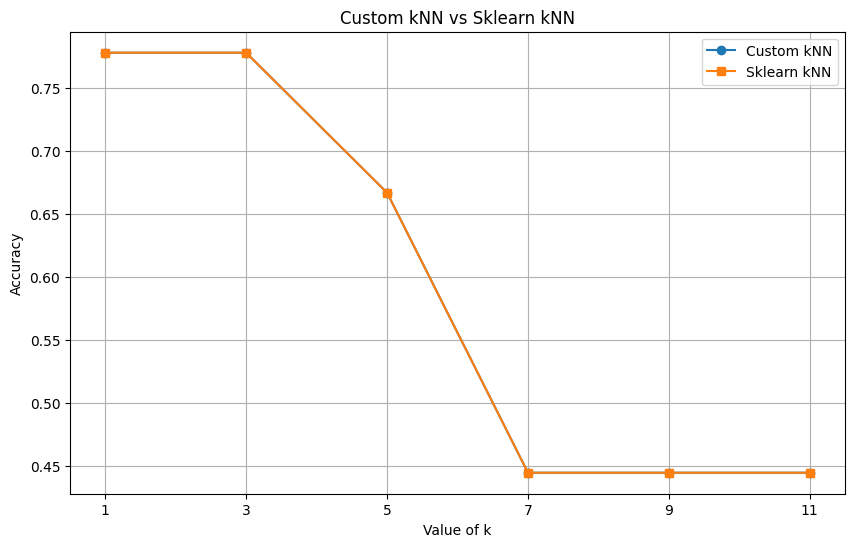

In [ ]:
# ============================================================
# A8 - COMPARISON FOR DIFFERENT K VALUES
# ============================================================

import matplotlib.pyplot as plt

k_values = [1, 3, 5, 7, 9, 11]

custom_accuracies = []
sklearn_accuracies = []

for k in k_values:

    # -----------------------------
    # CUSTOM KNN
    # -----------------------------

    custom_model = CustomKNN(
        k=k,
        metric="euclidean",
        sorting_algorithm="insertion",
        weighted=False
    )

    custom_model.fit(
        X_train,
        y_train
    )

    custom_acc = custom_model.score(
        X_test,
        y_test
    )

    custom_accuracies.append(
        custom_acc
    )


    # -----------------------------
    # SKLEARN KNN
    # -----------------------------

    sklearn_model = KNeighborsClassifier(
        n_neighbors=k
    )

    sklearn_model.fit(
        X_train,
        y_train
    )

    sklearn_acc = sklearn_model.score(
        X_test,
        y_test
    )

    sklearn_accuracies.append(
        sklearn_acc
    )


# ============================================================
# PRINT RESULTS
# ============================================================

print("========================================")
print("A8 - KNN COMPARISON")
print("========================================")

comparison_table = pd.DataFrame({
    "K": k_values,
    "Custom kNN Accuracy": custom_accuracies,
    "Sklearn kNN Accuracy": sklearn_accuracies
})

comparison_table["Custom Accuracy (%)"] = (
    comparison_table["Custom kNN Accuracy"] * 100
)

comparison_table["Sklearn Accuracy (%)"] = (
    comparison_table["Sklearn kNN Accuracy"] * 100
)

print(comparison_table)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    custom_accuracies,
    marker="o",
    label="Custom kNN"
)

plt.plot(
    k_values,
    sklearn_accuracies,
    marker="s",
    label="Sklearn kNN"
)

plt.xlabel("Value of k")
plt.ylabel("Accuracy")

plt.title(
    "Custom kNN vs Sklearn kNN"
)

plt.xticks(k_values)

plt.grid(True)

plt.legend()

plt.show()

A9)

A9 - WEIGHTED KNN COMPARISON
    K  Normal Custom kNN  Sklearn kNN  Weighted Custom kNN  Normal Custom (%)  \
0   1           0.777778     0.777778             0.777778          77.777778   
1   3           0.777778     0.777778             0.777778          77.777778   
2   5           0.666667     0.666667             0.666667          66.666667   
3   7           0.444444     0.444444             0.777778          44.444444   
4   9           0.444444     0.444444             0.777778          44.444444   
5  11           0.444444     0.444444             0.777778          44.444444   

   Sklearn (%)  Weighted Custom (%)  
0    77.777778            77.777778  
1    77.777778            77.777778  
2    66.666667            66.666667  
3    44.444444            77.777778  
4    44.444444            77.777778  
5    44.444444            77.777778  


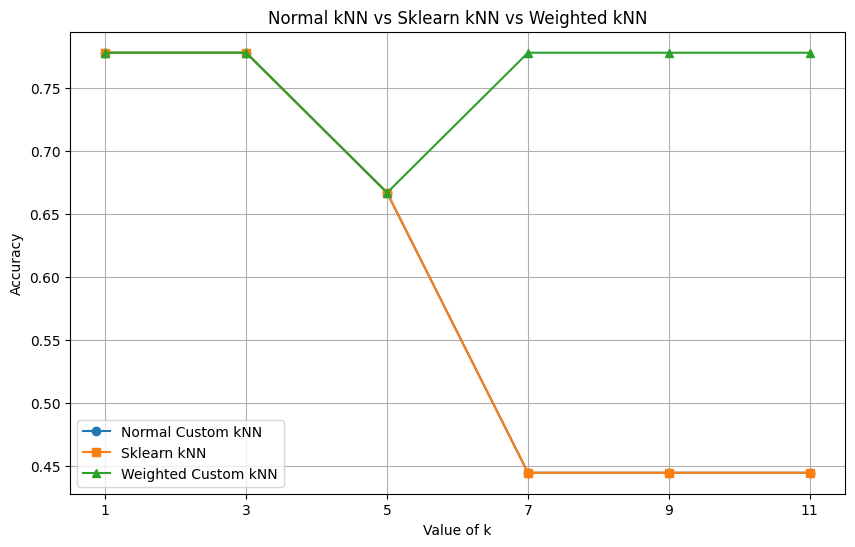

In [ ]:
# ============================================================
# A9 - WEIGHTED KNN COMPARISON
# ============================================================

weighted_accuracies = []

for k in k_values:

    weighted_model = CustomKNN(
        k=k,
        metric="euclidean",
        sorting_algorithm="insertion",
        weighted=True
    )

    weighted_model.fit(
        X_train,
        y_train
    )

    accuracy = weighted_model.score(
        X_test,
        y_test
    )

    weighted_accuracies.append(
        accuracy
    )


# ============================================================
# CREATE COMPARISON TABLE
# ============================================================

a9_table = pd.DataFrame({
    "K": k_values,
    "Normal Custom kNN": custom_accuracies,
    "Sklearn kNN": sklearn_accuracies,
    "Weighted Custom kNN": weighted_accuracies
})

a9_table["Normal Custom (%)"] = (
    a9_table["Normal Custom kNN"] * 100
)

a9_table["Sklearn (%)"] = (
    a9_table["Sklearn kNN"] * 100
)

a9_table["Weighted Custom (%)"] = (
    a9_table["Weighted Custom kNN"] * 100
)

print("========================================")
print("A9 - WEIGHTED KNN COMPARISON")
print("========================================")

print(a9_table)


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    custom_accuracies,
    marker="o",
    label="Normal Custom kNN"
)

plt.plot(
    k_values,
    sklearn_accuracies,
    marker="s",
    label="Sklearn kNN"
)

plt.plot(
    k_values,
    weighted_accuracies,
    marker="^",
    label="Weighted Custom kNN"
)

plt.xlabel("Value of k")

plt.ylabel("Accuracy")

plt.title(
    "Normal kNN vs Sklearn kNN vs Weighted kNN"
)

plt.xticks(k_values)

plt.grid(True)

plt.legend()

plt.show()